<a href="https://colab.research.google.com/github/issaalaje/assignment-2-AI/blob/main/Assignment_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
# importing neccessary libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
# Dataset Selection and Preprocessing
df = pd.read_csv('gender_classification.csv')
df.head()

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long,gender
0,1,11.8,6.1,1,0,1,1,Male
1,0,14.0,5.4,0,0,1,0,Female
2,0,11.8,6.3,1,1,1,1,Male
3,0,14.4,6.1,0,1,1,1,Male
4,1,13.5,5.9,0,0,0,0,Female


In [5]:
#Cleaning data by handling missing values and removing duplicates
df.isnull().sum()

,0
long_hair,0
forehead_width_cm,0
forehead_height_cm,0
nose_wide,0
nose_long,0
lips_thin,0
distance_nose_to_lip_long,0
gender,0


In [6]:
# Converting categorical data using encoding techniques
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])

In [9]:
# Splitting the dataset into training and testing sets
features = df.drop('gender',axis=1)
target = df['gender']
x_train,y_train,x_test,y_test = train_test_split(features,target,test_size=0.2,random_state=42)

In [12]:
# Exploratory Data Analysis (EDA):
# Perform an exploratory data analysis to visualize and summarize the data.
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5001 entries, 0 to 5000
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   long_hair                  5001 non-null   int64  
 1   forehead_width_cm          5001 non-null   float64
 2   forehead_height_cm         5001 non-null   float64
 3   nose_wide                  5001 non-null   int64  
 4   nose_long                  5001 non-null   int64  
 5   lips_thin                  5001 non-null   int64  
 6   distance_nose_to_lip_long  5001 non-null   int64  
 7   gender                     5001 non-null   int64  
dtypes: float64(2), int64(6)
memory usage: 312.7 KB


,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long,gender
count,5001.000000,5001.000000,5001.000000,5001.000000,5001.000000,5001.000000,5001.000000,5001.00000
mean,0.869626,13.181484,5.946311,0.493901,0.507898,0.493101,0.498900,0.49990
std,0.336748,1.107128,0.541268,0.500013,0.499988,0.500002,0.500049,0.50005
min,0.000000,11.400000,5.100000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,1.000000,12.200000,5.500000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,1.000000,13.100000,5.900000,0.000000,1.000000,0.000000,0.000000,0.00000
75%,1.000000,14.000000,6.400000,1.000000,1.000000,1.000000,1.000000,1.00000
max,1.000000,15.500000,7.100000,1.000000,1.000000,1.000000,1.000000,1.00000


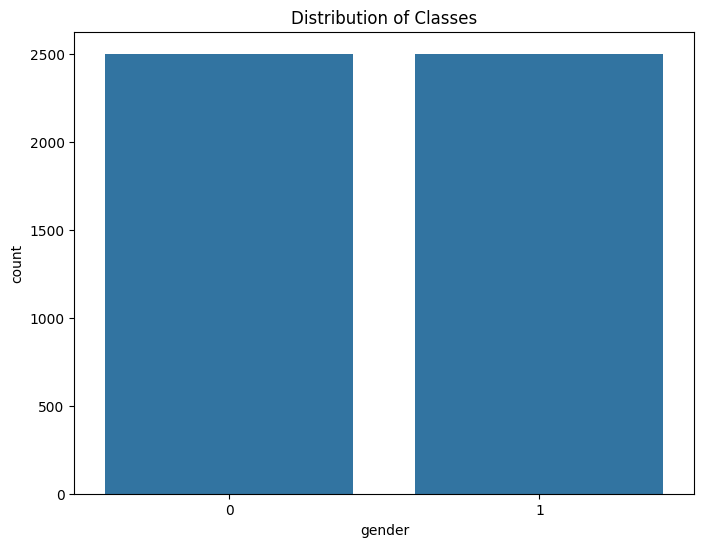

In [13]:
# Distribution of classes
plt.figure(figsize=(8,6))
sns.countplot(x='gender',data=df)
plt.title('Distribution of Classes')
plt.show()

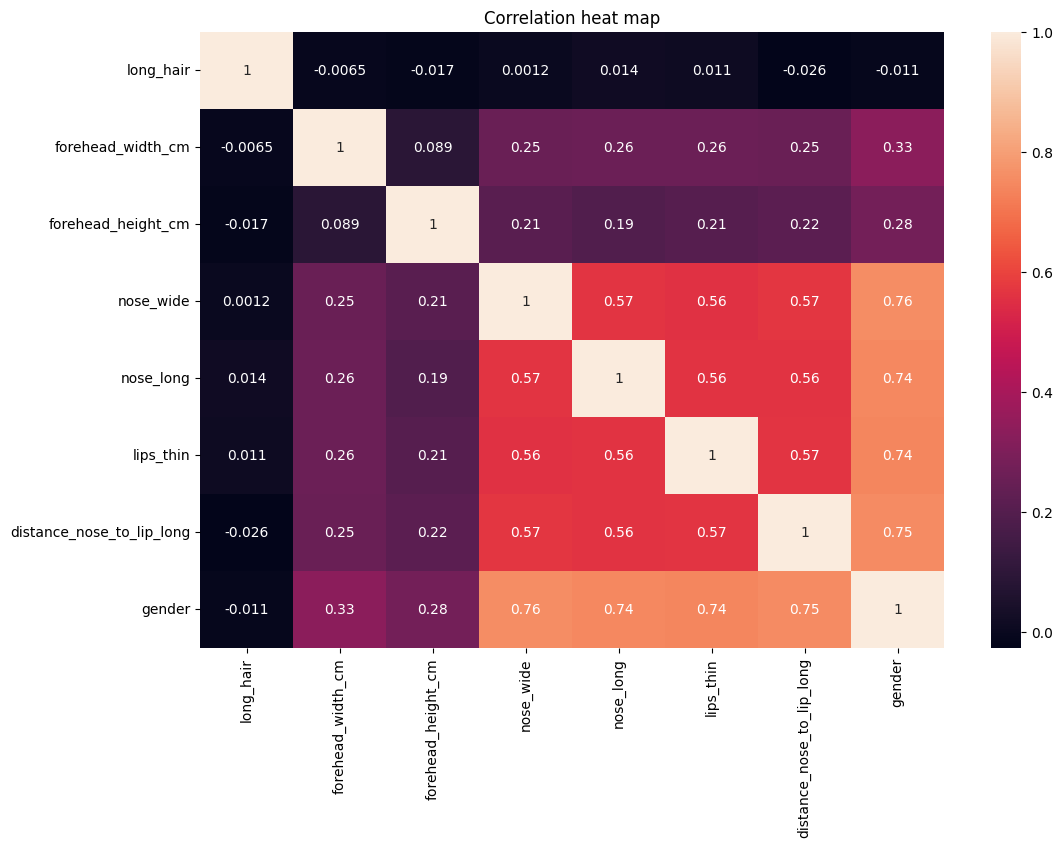

In [11]:
# Correlation between features
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),annot=True)
plt.title('Correlation heat map')
plt.show()

In [17]:
# Model Implementation and Evaluation:
# Implement at least two classification models (e.g., Logistic Regression, Support Vector Machines)
# Train the models on the training data.
model = LogisticRegression()
model.fit(x_train,x_test)
svm_model = SVC()
svm_model.fit(y_train,y_test)


SVC()

In [29]:
# Evaluate the logistic regression on the testing data using appropriate metrics (e.g., accuracy, precision, recall, F1-score, ROC-AUC)
print(confusion_matrix(model.predict(y_train),y_test))
print(classification_report(model.predict(y_train),y_test))



[[485  23]
 [ 17 476]]
              precision    recall  f1-score   support

           0       0.97      0.95      0.96       508
           1       0.95      0.97      0.96       493

    accuracy                           0.96      1001
   macro avg       0.96      0.96      0.96      1001
weighted avg       0.96      0.96      0.96      1001



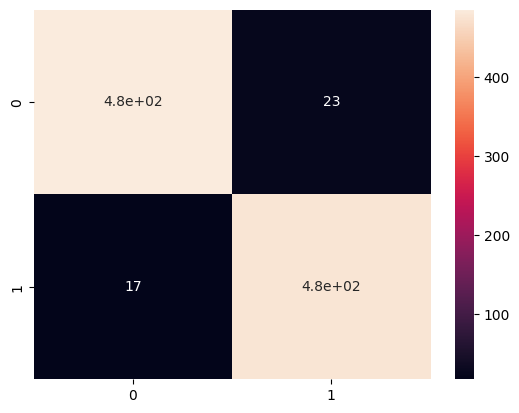

In [33]:
cm=confusion_matrix(model.predict(y_train),y_test)
sns.heatmap(cm,annot=True)
plt.show()

In [30]:
# Evaluate the Support Vector machines on the testing data using appropriate metrics (e.g., accuracy, precision, recall, F1-score, ROC-AUC).
print(confusion_matrix(svm_model.predict(y_train),y_test))
print(classification_report(svm_model.predict(y_train),y_test))

[[489  21]
 [ 13 478]]
              precision    recall  f1-score   support

           0       0.97      0.96      0.97       510
           1       0.96      0.97      0.97       491

    accuracy                           0.97      1001
   macro avg       0.97      0.97      0.97      1001
weighted avg       0.97      0.97      0.97      1001



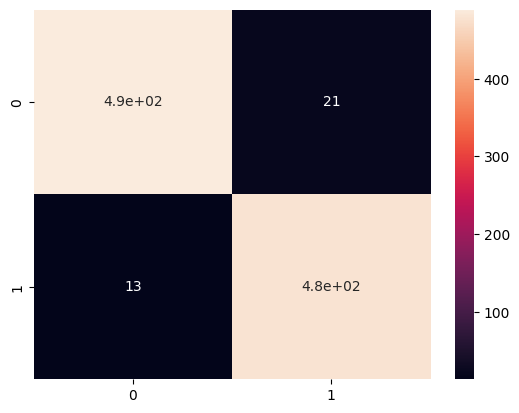

In [32]:
cm=confusion_matrix(svm_model.predict(y_train),y_test)
sns.heatmap(cm,annot=True)
plt.show()